# Milestone 4, step 0 — can a lake's 30 m ring be read?

`measure_rings.py` showed the rings are big enough to count: two clean 10 m pixels for every 10 m of
shore. This asks whether those pixels measure land. `measure_ring_greenness.py` measured the dry-season
greenness of every year 2019-2026 in each 10 m band of the ring around the 590 OSM lakes of 1 ha or
more (`results/m4_ring_table.csv`). Three tests, fixed in the decision log before these numbers existed:

1. **Grid check.** Earth Engine's pixel count must equal the local count in at least 99% of bands,
   or the grid is not the one counted. *It fails as written (58.6%), and the failure is not the grid:*
   pulling Earth Engine's own pixel centres for six mismatched bands gave the local centres exactly,
   every mismatch within 0.064 m of a band edge, where the round trip through EPSG:4326 decides a
   tie. The count test measured edge ties, not the grid. Replaced 2026-09-28 by that direct check;
   the count gaps are kept below because their size is what matters for a mean.
2. **Edge test.** If the middle band (10-20 m) is much noisier than the outer one (20-30 m) —
   median ratio of their scatter above 1.25 — the shore leaks into it and only 20-30 m is clean.
3. **Readability.** A lake is readable if M2's rank-40 loss (0.105) is at least 3x the noise of an
   endpoint change in its clean band, the noise taken as sqrt(2) x scatter: scatter <= 0.0247.

Values are normalised as in M2: each year minus the city-wide mean of the masked hex table. `scatter`
is the standard deviation of a band's eight normalised values about its own straight-line fit.
Runs without Earth Engine.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO))

YEARS = list(range(2019, 2027))
GRID_PASS = 0.99
LEAK_RATIO = 1.25
RANK40_LOSS = 0.105
MARGIN = 3
MAX_SCATTER = RANK40_LOSS / (MARGIN * np.sqrt(2))
INK = "#2b2b2b"

table = pd.read_csv("results/m4_ring_table.csv")
year_mean = pd.read_csv("results/m2_hex_table_masked.csv").pivot(index="h3", columns="year", values="green").mean(axis=0)
green = table[[f"green_{y}" for y in YEARS]].to_numpy() - year_mean[YEARS].to_numpy()
t = np.array(YEARS, float)
fit = np.polynomial.polynomial.polyfit(t, np.nan_to_num(green).T, 1)
residual = green - (fit[0][:, None] + fit[1][:, None] * t)
table["scatter"] = np.nanstd(residual, axis=1, ddof=2)
table["level"] = np.nanmean(green, axis=1)
table["change"] = green[:, -1] - green[:, 0]
rings = pd.read_csv("results/m4_ring_pixels.csv").set_index("osm")
print(f"{table.osm.nunique()} lakes, {len(table)} bands; max scatter allowed {MAX_SCATTER:.4f}")

590 lakes, 1770 bands; max scatter allowed 0.0247


---
## 1 — Grid check

The ±1 px gaps are symmetric around zero, which a shifted grid would not give on average across
1,770 bands of every shape; the direct pixel-centre check settles it.

In [2]:
gap = (table.n_pixels - table.local_px).abs()
share = (gap == 0).mean()
print(f"exact in {share:.1%} of bands; within 1 px in {(gap <= 1).mean():.1%}; largest gap {gap.max()} px "
      f"of {table.loc[gap.idxmax(), 'local_px']}")
per_band = table.pivot(index="osm", columns="band", values="local_px").reindex(rings.index.intersection(table.osm.unique()))
csv = rings.loc[per_band.index, ["px_0_10", "px_10_20", "px_20_30"]].set_axis(per_band.columns, axis=1)
print("band polygons vs measure_rings.py's distance count, median |gap|:",
      (per_band - csv).abs().median().to_dict())
print(f"mean gap {(table.n_pixels - table.local_px).mean():+.3f} px, 99th percentile of |gap| / pixels "
      f"{(gap / table.local_px).quantile(0.99):.1%}")
print("count test as written:", "PASS" if share >= GRID_PASS else "FAIL (edge ties, see above: grid confirmed by pixel centres)")

exact in 58.6% of bands; within 1 px in 90.4%; largest gap 7 px of 3022
band polygons vs measure_rings.py's distance count, median |gap|: {'0_10': 0.0, '10_20': 0.0, '20_30': 0.0}
mean gap -0.001 px, 99th percentile of |gap| / pixels 2.5%
count test as written: FAIL (edge ties, see above: grid confirmed by pixel centres)


---
## 2 — Edge test

Level, 2019→2026 change and scatter per band, median over lakes. Water or a moving shoreline shows
up first as scatter: a pixel that is water some years and weed or mud in others swings far more
than land does.

band       0_10   10_20   20_30
level    0.0668  0.0549  0.0432
change   0.0360  0.0258  0.0179
scatter  0.0429  0.0326  0.0276

median scatter ratio 10-20 / 20-30 = 1.147 (0-10 / 20-30 = 1.508) -> no leak: clean is 10-30 m


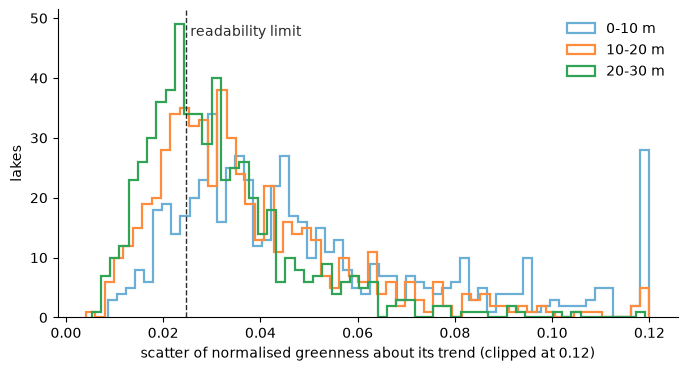

In [3]:
wide = table.pivot(index="osm", columns="band", values=["level", "change", "scatter"])
summary = wide.median().unstack().round(4)
print(summary.to_string())
ratio = (wide["scatter"]["10_20"] / wide["scatter"]["20_30"]).median()
inner = (wide["scatter"]["0_10"] / wide["scatter"]["20_30"]).median()
CLEAN = ("20_30",) if ratio > LEAK_RATIO else ("10_20", "20_30")
print(f"\nmedian scatter ratio 10-20 / 20-30 = {ratio:.3f} (0-10 / 20-30 = {inner:.3f}) -> "
      f"{'LEAK: clean is 20-30 m only' if ratio > LEAK_RATIO else 'no leak: clean is 10-30 m'}")

fig, ax = plt.subplots(figsize=(8, 4))
for band, colour in zip(("0_10", "10_20", "20_30"), ("#6baed6", "#fd8d3c", "#31a354")):
    ax.hist(wide["scatter"][band].clip(upper=0.12), bins=60, histtype="step", color=colour, lw=1.6,
            label=f"{band.replace('_', '-')} m")
ax.axvline(MAX_SCATTER, color=INK, ls="--", lw=1)
ax.text(MAX_SCATTER, ax.get_ylim()[1] * 0.95, " readability limit", color=INK, va="top")
ax.set_xlabel("scatter of normalised greenness about its trend (clipped at 0.12)")
ax.set_ylabel("lakes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

---
## 3 — Readability

The clean band's yearly values, pixel-weighted across its bands, give each lake one series; its
scatter decides readability.

readable: 209 of 590 lakes (35%)
        lakes  readable  median_scatter  median_px
size                                              
1-5       302     0.325           0.031      177.0
5-10      145     0.359           0.029      289.0
10-40     113     0.425           0.026      477.0
40-100     21     0.333           0.030      827.0
100+        9     0.444           0.076     1592.0


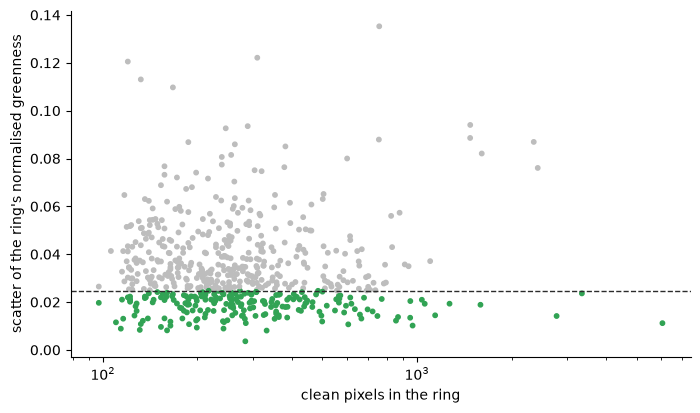

In [4]:
clean = table[table.band.isin(CLEAN)]
weights = clean.n_pixels.to_numpy()[:, None]
cols = [f"green_{y}" for y in YEARS]
values = clean[cols].to_numpy() * weights
series = (pd.DataFrame(values, index=clean.osm).groupby(level=0).sum()
          / pd.Series(weights[:, 0], index=clean.osm).groupby(level=0).sum().to_numpy()[:, None])
series.columns = YEARS
norm = series - year_mean[YEARS].to_numpy()
fit = np.polynomial.polynomial.polyfit(t, norm.to_numpy().T, 1)
res = norm.to_numpy() - (fit[0][:, None] + fit[1][:, None] * t)
lake = pd.DataFrame({
    "name": rings.loc[norm.index, "name"],
    "ha": rings.loc[norm.index, "ha"],
    "clean_px": clean.groupby("osm").n_pixels.sum().loc[norm.index],
    "scatter": np.std(res, axis=1, ddof=2),
    "change": norm[2026] - norm[2019],
}, index=norm.index)
lake["readable"] = lake.scatter <= MAX_SCATTER
lake["size"] = pd.cut(lake.ha, [1, 5, 10, 40, 100, np.inf], labels=["1-5", "5-10", "10-40", "40-100", "100+"], right=False)
print(f"readable: {lake.readable.sum()} of {len(lake)} lakes ({lake.readable.mean():.0%})")
print(lake.groupby("size", observed=True).agg(lakes=("ha", "size"), readable=("readable", "mean"),
      median_scatter=("scatter", "median"), median_px=("clean_px", "median")).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(lake.clean_px, lake.scatter, s=10, c=np.where(lake.readable, "#31a354", "#bdbdbd"))
ax.axhline(MAX_SCATTER, color=INK, ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("clean pixels in the ring")
ax.set_ylabel("scatter of the ring's normalised greenness")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

---
## 4 — First look: the biggest ring losses

Not verdicts. The 2019→2026 normalised change of each readable lake's clean ring, largest losses
first, as the list the M4 photo check starts from. Unreadable lakes with a loss past the rank-40
size are listed too: the scatter test can fail precisely because the loss was sudden.

In [5]:
pd.set_option("display.width", 160)
ranked = lake.sort_values("change")
print("readable, biggest losses:")
print(ranked[ranked.readable].head(20)[["name", "ha", "clean_px", "scatter", "change"]].round(3).to_string())
big = ranked[~ranked.readable & (ranked.change <= -RANK40_LOSS)]
print(f"\nunreadable but past the rank-40 loss: {len(big)}")
print(big.head(10)[["name", "ha", "clean_px", "scatter", "change"]].round(3).to_string())
lake.round(4).to_csv("results/m4_ring_lakes.csv")

readable, biggest losses:
                                name      ha  clean_px  scatter  change
osm                                                                    
w1178402476     Chittekarepalya Lake   1.096       122    0.021  -0.138
w172651060           Mylasandra Tank   3.164       184    0.022  -0.110
w987608929   Kachanayakanahalli lake   8.721       297    0.021  -0.096
w1180240726                      NaN   4.086       256    0.024  -0.090
r1853330             Vengayyana Lake  14.171       465    0.020  -0.085
w1382288524                      NaN   2.524       168    0.021  -0.075
w673791606                       NaN   1.474       122    0.020  -0.075
w1349913931   Beratena Agrahara Lake   5.171       236    0.022  -0.062
w41667653             Singapura Kere   8.083       329    0.015  -0.058
w1333664338                      NaN   5.283       386    0.021  -0.049
w23000626              Hulimavu Lake  41.148       678    0.022  -0.048
w145430164                       NaN  